# 심부전 환자 생존 예측: 데이터 누수 점검과 재평가

- 데이터: Kaggle *Heart Failure Clinical Records Dataset* (환자 299명, 입력 변수 12개, 목표 변수 `DEATH_EVENT`)
- 목표: 처음 분석에서 가장 중요한 변수였던 `time`(추적 관찰 기간)이 결과를 미리 반영한 **데이터 누수 변수**인지 확인하고, 이를 제거한 뒤 교차검증으로 모델을 다시 평가합니다.
- 처음 분석(수업 발표 버전)은 `EDA_proj.ipynb`에 있습니다.

## 1. 라이브러리 및 설정

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.inspection import permutation_importance

# 한글 폰트: 설치된 폰트 중 첫 번째 사용 (Windows: Malgun Gothic, macOS: AppleGothic)
_available = {f.name for f in font_manager.fontManager.ttflist}
for _name in ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR"]:
    if _name in _available:
        plt.rc("font", family=_name)
        break
plt.rc("axes", unicode_minus=False)
os.makedirs("images", exist_ok=True)

## 2. 데이터 불러오기

In [2]:
df = pd.read_csv("heart_failure_clinical_records_dataset.csv")
y = df["DEATH_EVENT"]
X_all = df.drop(columns="DEATH_EVENT")    # time 포함 (처음 분석과 같은 12개 변수)
X_nt = X_all.drop(columns="time")          # time 제외 (11개 변수)

print(f"환자 수: {len(df)}명, 결측치: {df.isnull().sum().sum()}개")
print(f"사망: {y.sum()}명 ({y.mean():.1%}) → 불균형 데이터")
df.head()

환자 수: 299명, 결측치: 0개
사망: 96명 (32.1%) → 불균형 데이터


,age,anaemia,creatinine_phosphokinase,diabetes,ejection_fraction,high_blood_pressure,platelets,serum_creatinine,serum_sodium,sex,smoking,time,DEATH_EVENT
0,75.0,0,582,0,20,1,265000.00,1.9,130,1,0,4,1
1,55.0,0,7861,0,38,0,263358.03,1.1,136,1,0,6,1
2,65.0,0,146,0,20,0,162000.00,1.3,129,1,1,7,1
3,50.0,1,111,0,20,0,210000.00,1.9,137,1,0,7,1
4,65.0,1,160,1,20,0,327000.00,2.7,116,0,0,8,1


## 3. 문제 확인: `time`은 왜 누수 변수인가

`time`은 환자를 얼마나 오래 관찰했는지를 뜻합니다. 사망한 환자는 사망 시점에 관찰이 끝나므로 관찰 기간이 짧을 수밖에 없습니다. 즉 `time`은 결과(사망)가 나온 뒤에야 알 수 있는 값이라, 실제 예측 시점에는 사용할 수 없습니다.

DEATH_EVENT
생존    172.0
사망     44.5


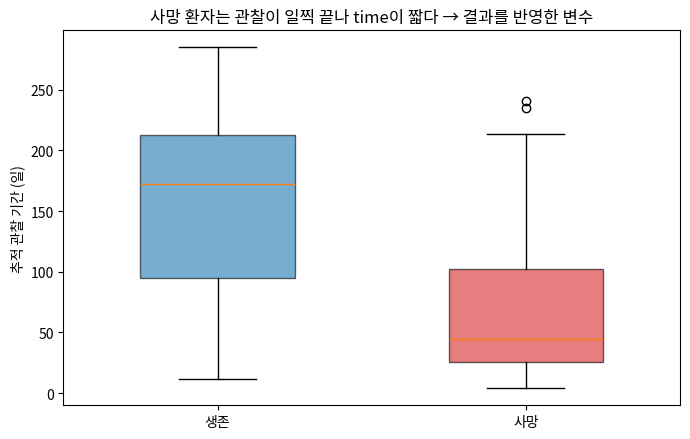

In [3]:
print(df.groupby("DEATH_EVENT")["time"].median().rename({0: "생존", 1: "사망"}).to_string())

fig, ax = plt.subplots(figsize=(7, 4.5))
lab = y.map({0: "생존", 1: "사망"})
bp = ax.boxplot([df.loc[lab == "생존", "time"], df.loc[lab == "사망", "time"]],
                patch_artist=True, widths=0.5)
ax.set_xticks([1, 2]); ax.set_xticklabels(["생존", "사망"])
for p, c in zip(bp["boxes"], ["#1f77b4", "#d62728"]):
    p.set_facecolor(c); p.set_alpha(0.6)
ax.set_ylabel("추적 관찰 기간 (일)")
ax.set_title("사망 환자는 관찰이 일찍 끝나 time이 짧다 → 결과를 반영한 변수")
plt.tight_layout(); plt.savefig("images/time_by_outcome.png", dpi=150); plt.show()

## 4. 평가 방법

- 데이터가 적어(299명) 한 번의 8:2 분할은 결과가 우연에 크게 흔들리므로, **층화 5겹 교차검증**으로 평균과 표준편차를 봅니다.
- 사망 비율이 32%로 불균형하므로 `class_weight="balanced"`를 적용하고, **ROC-AUC와 재현율**을 중심으로 봅니다.
- 정확도·정밀도·재현율·F1은 기본 임계값 0.5 기준입니다.

In [4]:
models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "KNN": make_pipeline(StandardScaler(), KNeighborsClassifier()),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced"),
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]

## 5. `time` 포함 vs 제외 성능 비교

In [5]:
rows = []
for setting, X in [("time 포함", X_all), ("time 제외", X_nt)]:
    for name, m in models.items():
        r = cross_validate(m, X, y, cv=cv, scoring=scoring)
        row = {"설정": setting, "모델": name}
        for s in scoring:
            row[s] = f"{r['test_' + s].mean():.3f} ± {r['test_' + s].std():.3f}"
            row[s + "_mean"] = r["test_" + s].mean()
        rows.append(row)
res = pd.DataFrame(rows)
res.to_csv("results.csv", index=False, encoding="utf-8-sig")
res[["설정", "모델"] + scoring]

,설정,모델,accuracy,precision,recall,f1,roc_auc
0,time 포함,Logistic Regression,0.796 ± 0.037,0.669 ± 0.076,0.771 ± 0.055,0.710 ± 0.024,0.877 ± 0.033
1,time 포함,KNN,0.742 ± 0.032,0.692 ± 0.094,0.354 ± 0.084,0.465 ± 0.089,0.751 ± 0.050
2,time 포함,Decision Tree,0.762 ± 0.047,0.625 ± 0.067,0.623 ± 0.125,0.622 ± 0.096,0.725 ± 0.067
3,time 포함,Random Forest,0.849 ± 0.039,0.812 ± 0.060,0.687 ± 0.090,0.743 ± 0.075,0.902 ± 0.024
4,time 제외,Logistic Regression,0.686 ± 0.041,0.504 ± 0.051,0.648 ± 0.143,0.564 ± 0.086,0.769 ± 0.055
5,time 제외,KNN,0.689 ± 0.048,0.529 ± 0.160,0.269 ± 0.084,0.356 ± 0.109,0.674 ± 0.061
6,time 제외,Decision Tree,0.686 ± 0.038,0.509 ± 0.064,0.461 ± 0.126,0.477 ± 0.094,0.627 ± 0.055
7,time 제외,Random Forest,0.729 ± 0.069,0.605 ± 0.129,0.429 ± 0.167,0.492 ± 0.153,0.762 ± 0.079


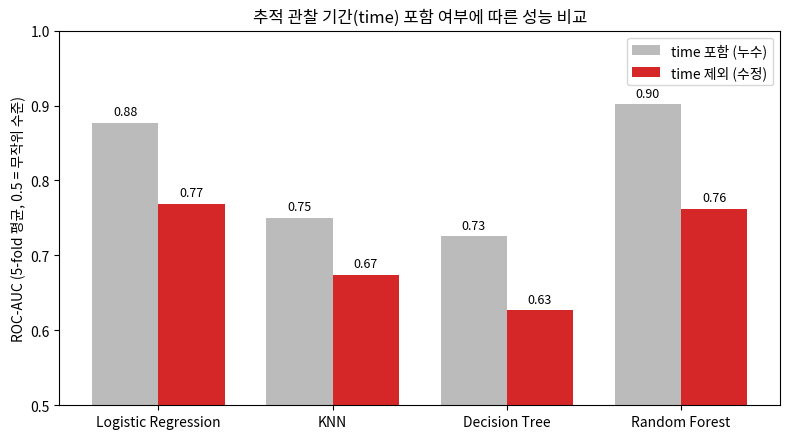

In [6]:
names = list(models)
x = np.arange(len(names)); w = 0.38
a = [res.query("설정 == 'time 포함' and 모델 == @n")["roc_auc_mean"].item() for n in names]
b = [res.query("설정 == 'time 제외' and 모델 == @n")["roc_auc_mean"].item() for n in names]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, a, w, label="time 포함 (누수)", color="#bbbbbb")
ax.bar(x + w/2, b, w, label="time 제외 (수정)", color="#d62728")
for i in range(len(names)):
    ax.text(x[i] - w/2, a[i] + 0.01, f"{a[i]:.2f}", ha="center", fontsize=9)
    ax.text(x[i] + w/2, b[i] + 0.01, f"{b[i]:.2f}", ha="center", fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0.5, 1.0); ax.set_ylabel("ROC-AUC (5-fold 평균, 0.5 = 무작위 수준)")
ax.set_title("추적 관찰 기간(time) 포함 여부에 따른 성능 비교")
ax.legend(); plt.tight_layout(); plt.savefig("images/auc_with_without_time.png", dpi=150); plt.show()

모든 모델에서 `time`을 빼면 ROC-AUC가 크게 떨어집니다. 처음 결과의 상당 부분이 누수 변수 덕분이었다는 뜻입니다.

## 6. ROC 곡선 (`time` 제외)

범례의 AUC는 5개 fold의 검증 예측을 하나로 합쳐 계산한 값이라, 위 표의 fold 평균값과 소수점 둘째 자리에서 조금 다를 수 있습니다.

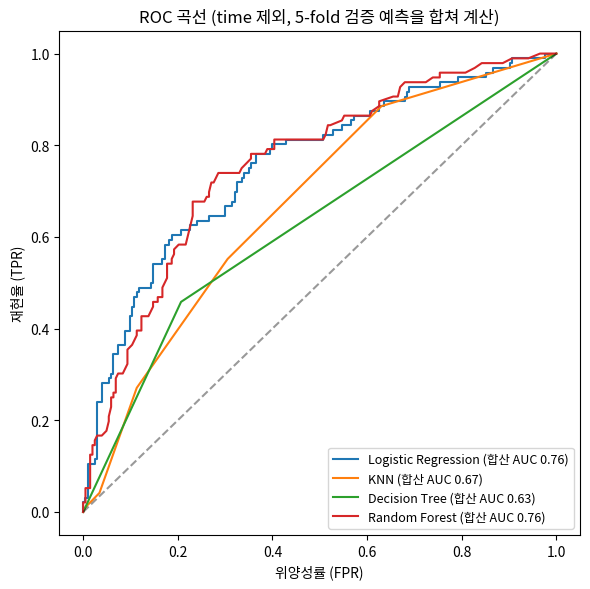

In [7]:
fig, ax = plt.subplots(figsize=(6, 6))
for name, m in models.items():
    p = cross_val_predict(m, X_nt, y, cv=cv, method="predict_proba")[:, 1]
    fpr, tpr, _ = roc_curve(y, p)
    ax.plot(fpr, tpr, label=f"{name} (합산 AUC {roc_auc_score(y, p):.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_xlabel("위양성률 (FPR)"); ax.set_ylabel("재현율 (TPR)")
ax.set_title("ROC 곡선 (time 제외, 5-fold 검증 예측을 합쳐 계산)")
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout(); plt.savefig("images/roc_no_time.png", dpi=150); plt.show()

## 7. 주요 변수: 순열 중요도 (`time` 제외 Random Forest)

각 검증 fold에서 변수 하나의 값을 무작위로 섞었을 때 ROC-AUC가 얼마나 떨어지는지로 중요도를 측정합니다. (Random Forest의 기본 불순도 기반 중요도는 연속형 변수를 과대평가하는 경향이 있어 사용하지 않았습니다.)

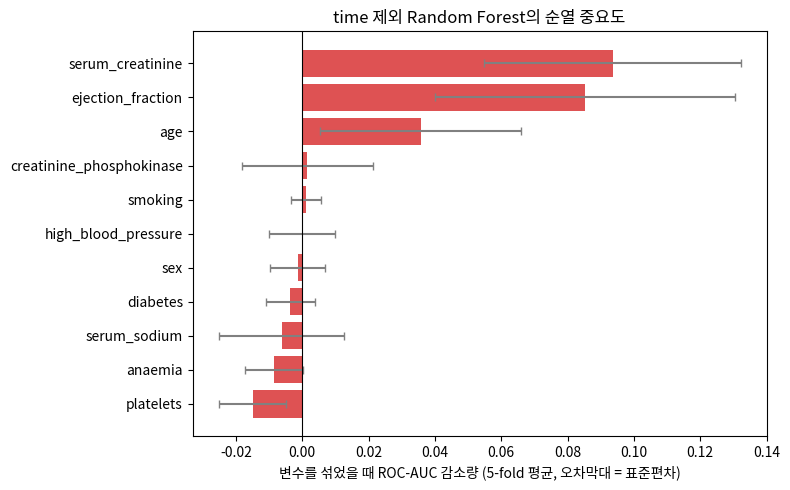

serum_creatinine            0.0936
ejection_fraction           0.0853
age                         0.0357
creatinine_phosphokinase    0.0015
smoking                     0.0011
high_blood_pressure        -0.0001
sex                        -0.0013
diabetes                   -0.0036
serum_sodium               -0.0062
anaemia                    -0.0086
platelets                  -0.0149
dtype: float64

In [8]:
perm = []
for tr, te in cv.split(X_nt, y):
    m = models["Random Forest"].fit(X_nt.iloc[tr], y.iloc[tr])
    r = permutation_importance(m, X_nt.iloc[te], y.iloc[te], scoring="roc_auc",
                               n_repeats=20, random_state=0)
    perm.append(r.importances_mean)
perm = pd.DataFrame(perm, columns=X_nt.columns)
imp = perm.mean().sort_values()
err = perm.std()[imp.index]

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(imp.index, imp.values, xerr=err.values, color="#d62728", alpha=0.8, ecolor="gray", capsize=3)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("변수를 섞었을 때 ROC-AUC 감소량 (5-fold 평균, 오차막대 = 표준편차)")
ax.set_title("time 제외 Random Forest의 순열 중요도")
plt.tight_layout(); plt.savefig("images/feature_importance_no_time.png", dpi=150); plt.show()
imp.sort_values(ascending=False).round(4)

## 8. 정리

- `time`은 결과를 반영한 누수 변수로, 제외하면 Random Forest의 ROC-AUC가 약 0.90에서 0.76으로 떨어집니다.
- `time` 제외 시 Random Forest는 정확도가 가장 높고, 로지스틱 회귀는 재현율이 가장 높습니다. 다만 fold 간 편차가 크고 통계적 검정은 하지 않았으므로 경향으로만 해석합니다.
- 예측에 가장 크게 기여한 변수는 혈청 크레아티닌, 심박출률, 나이였고, 나머지 변수의 순열 중요도는 0에 가까웠습니다.
- 한계: 단일 공개 데이터셋(299명), 외부 검증 없음, 하이퍼파라미터 튜닝 없음. 변수 중요도는 예측 기여도이며 인과관계를 뜻하지 않습니다.